# Packages

In [2]:
# Basic Package Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score
from sklearn.metrics import mean_squared_error, r2_score

# imblearn
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# Non-basic package imports
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import requests

# Packages I don't understand
from fcd_torch import FCD
import rdkit
from collections import Counter
import gc
import pickle

# Add the Python_files directory to the Python path
import sys
import os
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'Python_files'))

# Now you can import your modules
# import functions_enc as f
import function_depot as fd

# DF6 Spectra RF

In [5]:
# Load datasets folder path for df6
grid_search_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes_df6"

# Get all .parquet files in the folder
parquet_files = [f for f in os.listdir(grid_search_folder) if f.endswith('.parquet')]
dataset_names = [f.replace('.parquet', '') for f in parquet_files]

print(f"Found {len(dataset_names)} datasets to process")

# Verify we have the right count
thresh_zero_datasets = [name for name in dataset_names if 'thresh_zero' in name]
thresholded_datasets = [name for name in dataset_names if 'thresh_zero' not in name]

print(f"  - Datasets with thresh_zero: {len(thresh_zero_datasets)}")
print(f"  - Datasets with other thresholds: {len(thresholded_datasets)}")

# Initialize storage for results
results_r2 = []
results_percent_error = []

# Dictionary to store individual errors for histogram analysis
saved_spectral_errors = {}

# Process datasets ONE AT A TIME (memory efficient)
for i, dataset_name in enumerate(sorted(dataset_names), 1):
    print(f"Processing {i}/{len(dataset_names)}: {dataset_name}")
    
    try:
        # Load only the current dataset (parquet format)
        file_path = os.path.join(grid_search_folder, f"{dataset_name}.parquet")
        df = pd.read_parquet(file_path)
        
        # Prepare features and target
        feature_cols = [col for col in df.columns if col not in ['SMILES_spectra', 'Response', 'log_response', 'index_id']]
        X = df[feature_cols]
        y = df['log_response']
        
        # Remove rows with NaN values
        valid_mask = ~(X.isna().any(axis=1) | y.isna())
        X_clean = X[valid_mask]
        y_clean = y[valid_mask]
        
        if len(X_clean) < 10:  # Skip if too few samples
            print(f"  Skipping {dataset_name}: Only {len(X_clean)} valid samples")
            continue
            
        # Split the data
        X_train, X_test, y_train, y_test = train_test_split(
            X_clean, y_clean, test_size=0.5, random_state=42
        )
        
        # Train Random Forest with limited CPU usage
        rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=2)
        rf.fit(X_train, y_train)
        
        # Make predictions
        y_train_pred = rf.predict(X_train)
        y_test_pred = rf.predict(X_test)
        
        # Calculate R² metrics
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        
        # Calculate absolute percent error (undo log transform first)
        y_train_true_response = np.exp(y_train)
        y_train_pred_response = np.exp(y_train_pred)
        y_test_true_response = np.exp(y_test)
        y_test_pred_response = np.exp(y_test_pred)
        
        # Calculate individual errors for test set
        individual_errors = np.abs((y_test_pred_response - y_test_true_response) / y_test_true_response) * 100
        
        # Save individual errors for histogram analysis
        saved_spectral_errors[dataset_name] = individual_errors
        
        # Calculate median and mean absolute percent error
        train_median_percent_error = 100 * (np.median(np.abs(y_train_pred_response - y_train_true_response) / y_train_true_response))
        test_median_percent_error = 100 * (np.median(np.abs(y_test_pred_response - y_test_true_response) / y_test_true_response))
        train_mean_percent_error = 100 * (np.mean(np.abs(y_train_pred_response - y_train_true_response) / y_train_true_response))
        test_mean_percent_error = 100 * (np.mean(np.abs(y_test_pred_response - y_test_true_response) / y_test_true_response))

        # Store results
        results_r2.append({
            'Dataset': dataset_name,
            'Train_R2': train_r2,
            'Test_R2': test_r2,
            'Samples': len(X_clean),
            'Features': len(feature_cols)
        })
        
        results_percent_error.append({
            'Dataset': dataset_name,
            'Train_Median_Percent_Error': train_median_percent_error,
            'Test_Median_Percent_Error': test_median_percent_error,
            'Train_Mean_Percent_Error': train_mean_percent_error,
            'Test_Mean_Percent_Error': test_mean_percent_error,
            'Samples': len(X_clean),
            'Features': len(feature_cols)
        })
        
        print(f"Completed: Test R² = {test_r2:.4f}, Test Median % Error = {test_median_percent_error:.1f}%")
        
    except Exception as e:
        print(f"Error processing {dataset_name}: {str(e)}")
        continue
    
    finally:
        # Always clean up memory after each dataset
        if 'df' in locals():
            del df
        if 'X' in locals():
            del X, y, X_clean, y_clean
        if 'rf' in locals():
            del rf
        gc.collect()
        
        # Periodic deeper cleanup every 20 datasets
        if i % 20 == 0:
            print(f"  Deep cleanup after {i} datasets...")
            gc.collect()

# Convert results to DataFrames
df_r2_results = pd.DataFrame(results_r2)
df_percent_error_results = pd.DataFrame(results_percent_error)

print(f"\nCompleted! Processed {len(results_r2)} datasets successfully.")
print(f"Saved individual errors for {len(saved_spectral_errors)} datasets")
print(f"Results stored in: df_r2_results, df_percent_error_results")

Found 169 datasets to process
  - Datasets with thresh_zero: 13
  - Datasets with other thresholds: 156
Processing 1/169: bin0_05_thresh0_001_df_spectra
Completed: Test R² = 0.4394, Test Median % Error = 47.6%
Processing 2/169: bin0_05_thresh0_005_df_spectra
Completed: Test R² = 0.4360, Test Median % Error = 47.9%
Processing 3/169: bin0_05_thresh0_01_df_spectra
Completed: Test R² = 0.4380, Test Median % Error = 47.9%
Processing 4/169: bin0_05_thresh0_05_df_spectra
Completed: Test R² = 0.4397, Test Median % Error = 47.7%
Processing 5/169: bin0_05_thresh0_1_df_spectra
Completed: Test R² = 0.4393, Test Median % Error = 48.0%
Processing 6/169: bin0_05_thresh0_5_df_spectra
Completed: Test R² = 0.4331, Test Median % Error = 48.0%
Processing 7/169: bin0_05_thresh100_df_spectra
Completed: Test R² = -0.0000, Test Median % Error = 74.9%
Processing 8/169: bin0_05_thresh10_df_spectra
Completed: Test R² = 0.3263, Test Median % Error = 51.1%
Processing 9/169: bin0_05_thresh1_df_spectra
Completed: Te

# DF6 Spectra Heatmap

Checking for duplicates in results...
Original df_r2_results shape: (169, 7)
After removing duplicates: (169, 7)
Creating detailed heatmaps...


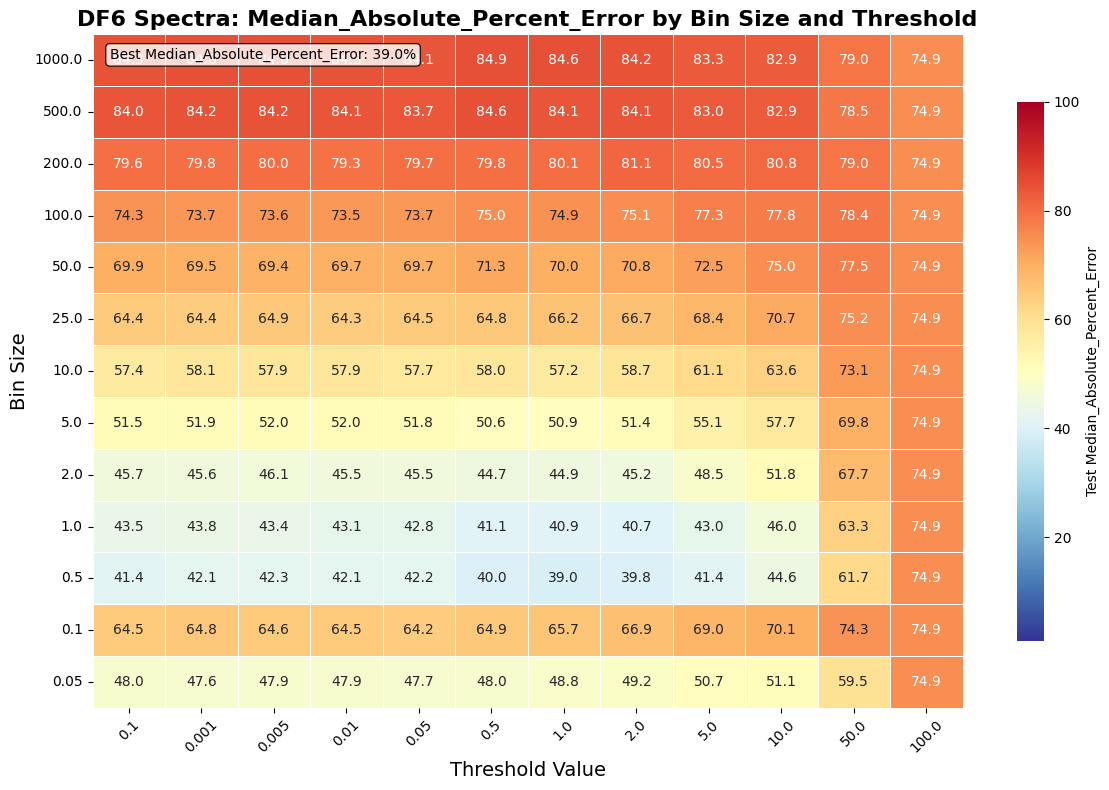

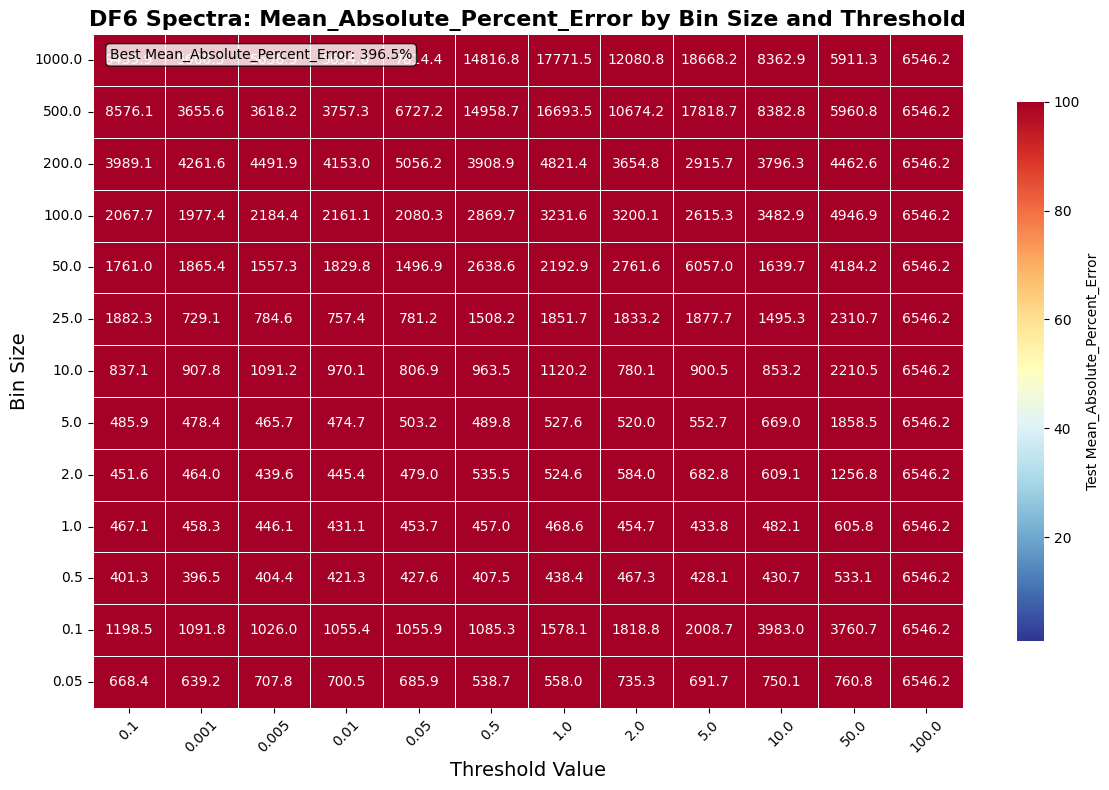

In [6]:
# Create the actual heatmaps for visualization
# First, let's extract bin size and threshold from the dataset names and add to results
def parse_dataset_name(dataset_name):
    """Extract bin size and threshold from dataset name"""
    # Handle thresh_zero case (no threshold)
    if 'thresh_zero' in dataset_name:
        # Extract bin size
        bin_part = dataset_name.split('_thresh_zero')[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        threshold = 0.0
    else:
        # Extract bin size and threshold
        parts = dataset_name.split('_thresh')
        bin_part = parts[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        
        thresh_part = parts[1].split('_df_spectra')[0]
        threshold = float(thresh_part.replace('_', '.'))
    
    return bin_size, threshold
    return bin_size, threshold

# Add bin_size and threshold columns to results DataFrames
for df_results in [df_r2_results, df_percent_error_results]:
    bin_sizes = []
    thresholds = []
    
    for dataset_name in df_results['Dataset']:
        bin_size, threshold = parse_dataset_name(dataset_name)
        bin_sizes.append(bin_size)
        thresholds.append(threshold)
    
    df_results['BinSize'] = bin_sizes
    df_results['Threshold'] = thresholds

# Check for and remove duplicates before creating pivot tables
print("Checking for duplicates in results...")
print(f"Original df_r2_results shape: {df_r2_results.shape}")

# Remove duplicates based on BinSize + Threshold combination (keep first occurrence)
df_r2_results = df_r2_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')
df_percent_error_results = df_percent_error_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')

print(f"After removing duplicates: {df_r2_results.shape}")

# Now create pivot tables 
r2_pivot = df_r2_results.pivot(index='BinSize', columns='Threshold', values='Test_R2') 
median_percent_error_pivot = df_percent_error_results.pivot(index='BinSize', columns='Threshold', values='Test_Median_Percent_Error')
mean_percent_error_pivot = df_percent_error_results.pivot(index='BinSize', columns='Threshold', values='Test_Mean_Percent_Error')

# List all expected thresholds (updated for df6 naming convention)
thresholds_subset = [0.1, 0.001, 0.005, 0.01, 0.05, 0.5, 1, 2, 5, 10, 50, 100]
bins_subset = [0.05, 0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500, 1000]

# Reindex pivot tables to show all columns, filling missing with NaN
r2_pivot = r2_pivot.reindex(columns=thresholds_subset, index=bins_subset)
median_percent_error_pivot = median_percent_error_pivot.reindex(columns=thresholds_subset, index=bins_subset)
mean_percent_error_pivot = mean_percent_error_pivot.reindex(columns=thresholds_subset, index=bins_subset)

# Also create individual larger heatmaps for better detail
def create_detailed_heatmap_spec(pivot_data, metric_name, cmap, figsize=(12, 8), vmin=None, vmax=None):
    """Create a detailed heatmap for a single metric"""
    plt.figure(figsize=figsize)
    
    # Create heatmap
    sns.heatmap(pivot_data, 
                annot=True, 
                fmt='.3f' if 'R²' in metric_name else '.1f', 
                cmap=cmap,
                square=False,
                linewidths=0.5,
                vmin=vmin,
                vmax=vmax,
                cbar_kws={'label': f'Test {metric_name}', 'shrink': 0.8})
    
    plt.title(f'DF6 Spectra: {metric_name} by Bin Size and Threshold', fontsize=16, fontweight='bold')
    plt.xlabel('Threshold Value', fontsize=14)
    plt.ylabel('Bin Size', fontsize=14)
    plt.gca().invert_yaxis()
    
    # Improve readability
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    # Add text annotation for best performance
    if 'R²' in metric_name:
        best_val = pivot_data.max().max()
        plt.text(0.02, 0.98, f'Best R²: {best_val:.4f}', 
                transform=plt.gca().transAxes, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                verticalalignment='top')
    else:
        best_val = pivot_data.min().min()
        plt.text(0.02, 0.98, f'Best {metric_name}: {best_val:.1f}%', 
                transform=plt.gca().transAxes, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                verticalalignment='top')
    
    plt.tight_layout()
    plt.savefig(f"/home/dlipsey/MITLincolnLabs/Figures/DF6_Spectra_{metric_name}_by_Bin_Size_and_Threshold")
    plt.show()

# Create detailed individual heatmaps
print("Creating detailed heatmaps...")

# create_detailed_heatmap_spec(r2_pivot, 'R²', 'RdYlBu')     
create_detailed_heatmap_spec(median_percent_error_pivot, 'Median_Absolute_Percent_Error', 'RdYlBu_r', vmin=1.0, vmax=100.0) 
create_detailed_heatmap_spec(mean_percent_error_pivot, 'Mean_Absolute_Percent_Error', 'RdYlBu_r', vmin=1.0, vmax=100.0)